In [1]:
import gc
import os
import multiprocessing
from torchvision.transforms import v2
from climate_cnn import ClimateCNN
from koppen_dataset import KoppenDataset
import torch
import torch.nn as nn
import tensorflow as tf
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split, KFold
import numpy as np
from torch.amp import autocast
from tqdm.auto import tqdm
from model.dataloader import load_shards
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import seaborn as sns

In [2]:
# 1. Is CUDA available?
print(f"Is CUDA available? {torch.cuda.is_available()}")

# 2. Which version of CUDA was PyTorch built with?
print(f"PyTorch CUDA version: {torch.version.cuda}")

# 3. What is the name of your GPU?
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("PyTorch cannot find your GPU.")

Is CUDA available? True
PyTorch CUDA version: 12.8
GPU Name: NVIDIA GeForce RTX 3070


In [3]:
# Force TensorFlow to use CPU only so PyTorch has the whole GPU
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Verify TF doesn't see the GPU
print(tf.config.list_physical_devices('GPU')) # Should return []

[]


In [4]:
# Load the data from the drive
# Use your local filepath here
file_pattern = r'G:/.shortcut-targets-by-id/1abX3CWvYUSJM3cGg6r_GeHAVeNoYH6Ul/CS6140_Project_Data/koppen_shard_part_*.tfrecord.gz'
all_files = tf.io.gfile.glob(file_pattern)

print(len(all_files), 'shards loaded')

# Split training, validation, and testing data
train_val_files, test_files = train_test_split(all_files, test_size=0.1, random_state=42)
train_files, val_files = train_test_split(train_val_files, test_size=0.2, random_state=42)
print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

1500 shards loaded
Train: 1080 | Val: 270 | Test: 150


In [5]:
# Function to calculate mean and std of training and testing sets
def calculate_stats(tf_dataset, num_samples=5000):
    images_iterator = tf_dataset.unbatch().take(num_samples).as_numpy_iterator()
    all_images = np.stack([img for img, _ in images_iterator])

    means = np.mean(all_images, axis=(0, 1, 2))
    stds = np.std(all_images, axis=(0, 1, 2))

    return means.tolist(), stds.tolist()

In [6]:
# Load raw data to calculate normalization statistics
loader_batch_size = 64
cores = multiprocessing.cpu_count()
train_raw = load_shards(train_files, batch_size=loader_batch_size)
test_raw = load_shards(test_files, batch_size=loader_batch_size)
train_means, train_stds = calculate_stats(train_raw)

# Minimal transforms to perform on CPU
cpu_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=False),
])

# For Training: High variety to fight overfitting
train_gpu_transforms = v2.Compose([
    v2.Resize(224, antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(180),
    v2.RandomResizedCrop(224, scale=(0.8, 1.0), antialias=True),
    v2.Normalize(mean=train_means, std=train_stds) # Normalizing on GPU is faster
])

# For Validation: No randomness
val_gpu_transforms = v2.Compose([
    v2.Resize(224, antialias=True),
    v2.Normalize(mean=train_means, std=train_stds)
])

# Create test dataloader
test_loader = DataLoader(
    KoppenDataset(test_raw, cpu_transforms),
    batch_size=None,
    pin_memory=True
)

In [7]:
# Function for checkpointing model during training
def save_checkpoint(state, filename="models/koppen_checkpoint.pth"):
    print(f"=> Saving best model to {filename}")
    torch.save(state, filename)

In [8]:
# Function for loading model checkpoint
def load_checkpoint(checkpoint_path, model, optimizer, scheduler):
    print(f"=> Loading checkpoint '{checkpoint_path}'")
    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    scheduler.load_state_dict(checkpoint['scheduler'])
    start_epoch = checkpoint['epoch']
    best_accuracy = checkpoint['best_acc']

    return model, optimizer, scheduler, start_epoch, best_accuracy

In [9]:
# Training Loop Function
def train_model(
        model,
        train_dataloader,
        test_dataloader,
        criterion,
        optimizer,
        scheduler,
        train_steps=None,
        num_epochs=10,
        start_epoch=0,
        best_val_acc=0,
        fold=None,
        patience=7
):
    # Set device to CUDA GPU if enabled
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    best_val_acc = best_val_acc
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    total_steps = train_steps if train_steps is not None else None
    final_epoch = 0

    training_losses = []
    training_accuracies = []
    validation_losses = []
    validation_accuracies = []

    for epoch in range(start_epoch, num_epochs):
        # --- Training ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        progress_bar = tqdm(train_dataloader, total=total_steps, desc=f"Epoch {epoch + 1}/{num_epochs} [Train]")

        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)

            # Apply image augmentation
            images = train_gpu_transforms(images)

            optimizer.zero_grad()

            # Forward pass with auto-casting
            with autocast(device_type='cuda', dtype=torch.bfloat16):
                outputs = model(images)
                loss = criterion(outputs, labels)

            # Backward pass with scaled loss
            loss.backward()
            optimizer.step()

            # Statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Update progress bar with current memory usage
            mem = torch.cuda.memory_reserved(0) / 1024**2
            progress_bar.set_postfix({"Loss": f"{loss.item():.4f}", "Acc": f"{100.*correct/total:.2f}%", "VRAM": f"{mem:.0f}MB"})

        # Append training loss/accuracy to plot data
        training_losses.append(running_loss / total)
        training_accuracies.append(100 * correct / total)

        # --- Validation ---
        model.eval()
        validation_loss = 0.0
        validation_correct = 0
        validation_total = 0

        with torch.no_grad():
            for images, labels in test_dataloader:
                images, labels = images.to(device), labels.to(device)

                # Apply image augmentation
                images = val_gpu_transforms(images)

                with autocast(device_type='cuda', dtype=torch.bfloat16):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                validation_loss += loss.item()
                _, predicted = outputs.max(1)
                validation_total += labels.size(0)
                validation_correct += (predicted == labels).sum().item()

        avg_val_loss = validation_loss / validation_total
        current_val_acc = 100. * validation_correct / validation_total

        # Step the LR scheduler
        scheduler.step(avg_val_loss)

        # Append validation loss/accuracy to plot data
        validation_losses.append(avg_val_loss)
        validation_accuracies.append(current_val_acc)

        # Check if this is the best version so far
        if current_val_acc > best_val_acc:
            best_val_acc = current_val_acc
            save_checkpoint(
                {
                    'epoch': epoch + 1,
                    'state_dict': model.state_dict(),
                    'optimizer': optimizer.state_dict(),
                    'scheduler': scheduler.state_dict(),
                    'best_acc': best_val_acc,
                    'means': train_means,
                    'stds': train_stds
                },
                filename=f"models/koppen_checkpoint_fold_{fold}.pth"
            )

        final_epoch = epoch + 1

        # Early stopping logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement == patience:
            print(f"{patience} epochs without validation loss improvement -- Early stopping triggered!")
            break

        print(f"--- Epoch {epoch + 1} Summary: Train Acc: {100. * correct / total:.2f}% | Val Acc: {current_val_acc:.2f}% ---")

    return training_losses, validation_losses, training_accuracies, validation_accuracies, final_epoch

In [10]:
# K-Fold Cross Validation Function
def run_kfold(files, k=5, num_epochs=20):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    # To store the final performance of each fold
    all_fold_val_accuracies = []
    model_dict = {}

    for fold, (train_idx, val_idx) in enumerate(kf.split(files)):
        print(f"\n" + "="*30)
        print(f" STARTING FOLD {fold + 1} / {k} ")
        print("="*30)

        # Split shards for this fold
        train_files_fold = [files[i] for i in train_idx]
        val_files_fold = [files[i] for i in val_idx]

        # Initialize dataloaders using the same global train_means/train_stds calculated
        # previously (technically leakage, but sample size is large)
        train = load_shards(train_files_fold, batch_size=loader_batch_size)
        val = load_shards(val_files_fold, batch_size=loader_batch_size)

        fold_train_steps = sum(1 for _ in train.as_numpy_iterator())
        training_loader = DataLoader(
            KoppenDataset(train, cpu_transforms), batch_size=None, pin_memory=True
        )
        validation_loader = DataLoader(
            KoppenDataset(val, cpu_transforms), batch_size=None, pin_memory=True
        )

        # Reset Model, Optimizer, and Scheduler
        cnn_model = ClimateCNN(num_classes=30)

        # Set up the optimizer, scheduler, and loss criterion
        optim = torch.optim.AdamW(cnn_model.parameters(), lr=1e-4, weight_decay=1.0)
        lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, 'min', patience=3, factor=0.5)
        loss_func = nn.CrossEntropyLoss()

        # Train the model for this fold
        model_history = train_model(
            model=cnn_model,
            train_dataloader=training_loader,
            test_dataloader=validation_loader,
            train_steps=fold_train_steps,
            criterion=loss_func,
            optimizer=optim,
            scheduler=lr_scheduler,
            num_epochs=num_epochs,
            fold=fold
        )

        # Extract the best validation accuracy from this fold's history
        best_accuracy = max(model_history[3])
        all_fold_val_accuracies.append(best_accuracy)

        print(f"\n>> Fold {fold + 1} Complete. Best Val Accuracy: {best_accuracy:.2f}%")

        model_dict[fold] = [cnn_model, best_accuracy, model_history]

    # Final Summary
    print(f"\n" + "!"*30)
    print(f"K-FOLD CROSS-VALIDATION COMPLETE")
    print(f"Average Accuracy: {np.mean(all_fold_val_accuracies):.2f}% (+/- {np.std(all_fold_val_accuracies):.2f}%)")
    print("!"*30)

    return model_dict

In [11]:
# Empty cache from previous runs
torch.cuda.empty_cache()
gc.collect()

epochs = 30

# Execute the training
models = run_kfold(train_val_files, k=5, num_epochs=epochs)

# Get the best model
cnn, best_acc, history = max(models.values(), key=lambda x: x[1])
train_loss, val_loss, train_acc, val_acc, last_epoch = history

# Save best model
torch.save(cnn.state_dict(), "models/koppen_cnn_resnet50_wd10.pth")


 STARTING FOLD 1 / 5 


Epoch 1/30 [Train]:   0%|          | 0/664 [00:00<?, ?it/s]

=> Saving best model to models/koppen_checkpoint_fold_0.pth
--- Epoch 1 Summary: Train Acc: 36.65% | Val Acc: 43.80% ---


Epoch 2/30 [Train]:   0%|          | 0/664 [00:00<?, ?it/s]

=> Saving best model to models/koppen_checkpoint_fold_0.pth
--- Epoch 2 Summary: Train Acc: 51.17% | Val Acc: 52.06% ---


...

--- Epoch 19 Summary: Train Acc: 81.87% | Val Acc: 67.81% ---


Epoch 20/30 [Train]:   0%|          | 0/668 [00:00<?, ?it/s]

--- Epoch 20 Summary: Train Acc: 83.32% | Val Acc: 65.63% ---


Epoch 21/30 [Train]:   0%|          | 0/668 [00:00<?, ?it/s]

7 epochs without validation loss improvement -- Early stopping triggered!

>> Fold 5 Complete. Best Val Accuracy: 67.87%

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
K-FOLD CROSS-VALIDATION COMPLETE
Average Accuracy: 66.92% (+/- 0.87%)
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [12]:
def plot_per_class_f1():
    cnn.eval()
    y_true = []
    y_pred = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            inputs = val_gpu_transforms(inputs)
            outputs = cnn(inputs)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Calculate F1 Scores
    # These are the standard 30 Köppen-Geiger classes
    class_names = [
        'Af', 'Am', 'Aw', 'BWh', 'BWk', 'BSh', 'BSk',
        'Csa', 'Csb', 'Csc', 'Cfa', 'Cfb', 'Cfc', 'Cwa', 'Cwb', 'Cwc',
        'Dsa', 'Dsb', 'Dsc', 'Dsd', 'Dfa', 'Dfb', 'Dfc', 'Dfd', 'Dwa', 'Dwb', 'Dwc', 'Dwd',
        'ET', 'EF'
    ]

    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    f1_scores = {k: v['f1-score'] for k, v in report.items() if k in class_names}

    # Plotting
    sorted_f1 = dict(sorted(f1_scores.items(), key=lambda item: item[1]))

    plt.figure(figsize=(12, 8))
    sns.barplot(x=list(sorted_f1.values()), y=list(sorted_f1.keys()), palette="viridis", hue=list(sorted_f1.keys()), legend=False)
    plt.axvline(x=float(np.mean(list(f1_scores.values()))), color='red', linestyle='--', label=f'Mean F1: {np.mean(list(f1_scores.values())):.2f}')
    plt.title("Per-Class Testing F1-Score (Sorted)")
    plt.xlabel("F1-Score")
    plt.ylabel("Climate Class")
    plt.legend()
    plt.show()

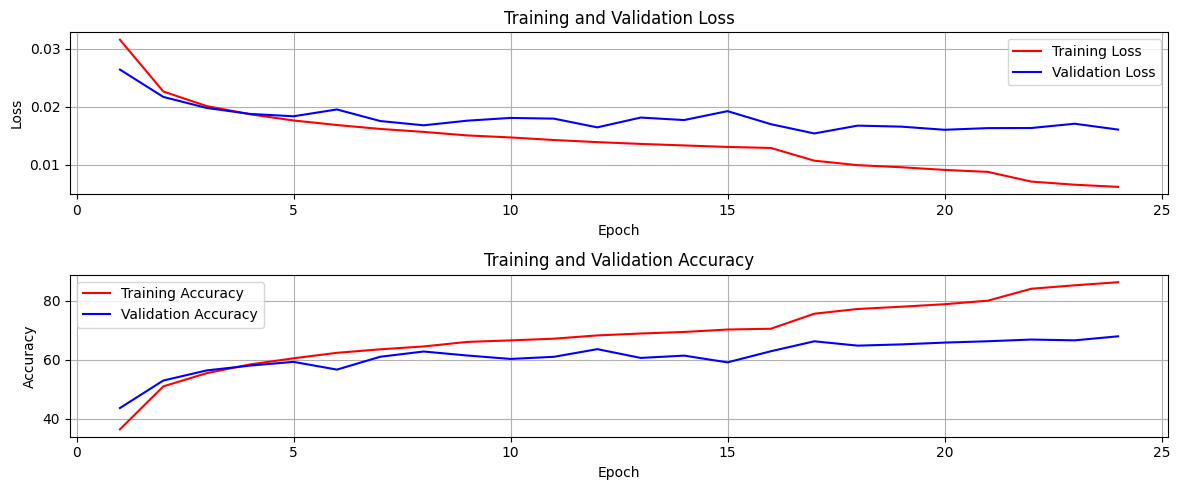

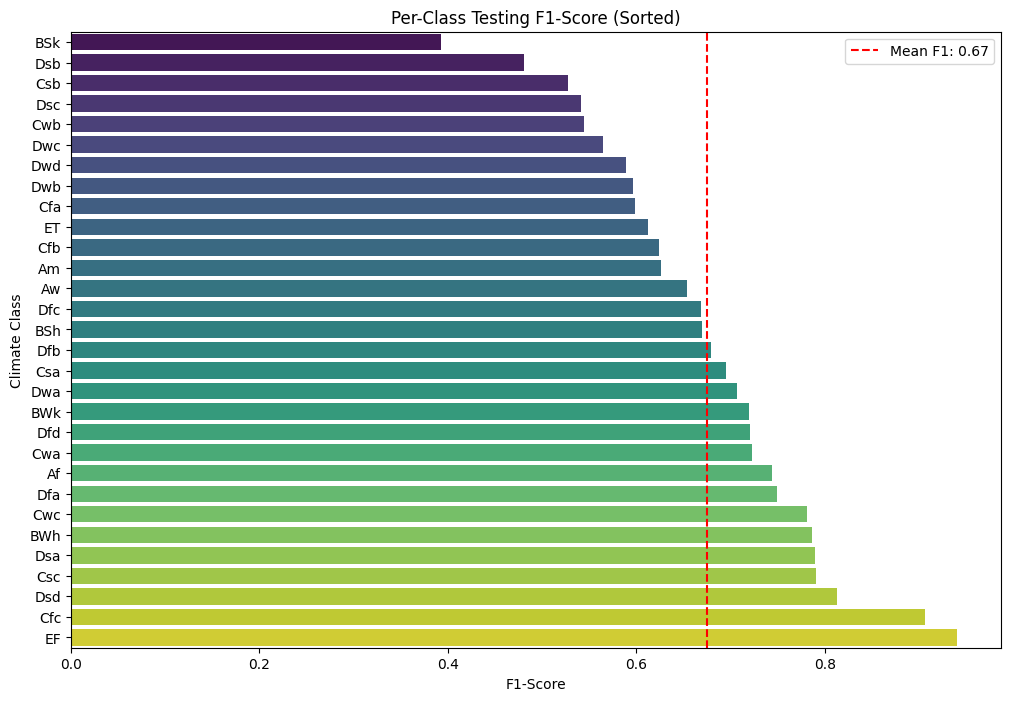

In [13]:
plt.figure(figsize=(12, 5))

# Plot the losses
plt.subplot(2, 1, 1)
plt.plot(np.arange(1, last_epoch + 1), train_loss, 'r-', label='Training Loss')
plt.plot(np.arange(1, last_epoch + 1), val_loss, 'b-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot the accuracies
plt.subplot(2, 1, 2)
plt.plot(np.arange(1, last_epoch + 1), train_acc, 'r-', label='Training Accuracy')
plt.plot(np.arange(1, last_epoch + 1), val_acc, 'b-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plot_per_class_f1()